# 01b — Analyse fréquentielle des débits — Hérault (34)

| Méthode | Description | Bibliothèque |
|---------|-------------|--------------|
| **Maxima annuels** | Obs. journalières → max par année hydrologique | Hub'Eau v2 `obs_elaborees` |
| **GEV** | Loi des valeurs extrêmes généralisée (GEV/EV1/EV2) | `scipy.stats.genextreme` |
| **Gumbel** | GEV avec ξ=0 (méthode standard France) | `scipy.stats.gumbel_r` |
| **Log-Normale** | LN2 (2 paramètres) | `scipy.stats.lognorm` |
| **Bootstrap** | Intervalles de confiance à 95% (n=1000 tirages) | `numpy` |

**Scénarios TRI** : T10 🟢 (fréquent), T100 🟠 (moyen), T1000 🟣 (extrême)  
**Graphiques** : Plotly — courbes de fréquences (axe log), chroniques, comparaison multi-stations  
> ⚠️ Si Hub'Eau `obs_elaborees` ne retourne pas de données, données synthétiques Gumbel générées automatiquement pour démonstration.

In [1]:
!pip install requests pandas numpy scipy plotly leafmap mapclassify 2>/dev/null | tail -3

In [2]:
import warnings, os, time
import requests
import pandas as pd
import numpy as np
import geopandas as gpd
from scipy import stats
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from IPython.display import display
warnings.filterwarnings('ignore')

# ── Constantes ──────────────────────────────────────────────────────────────
DEPT_CODE = '34'
DEPT_NAME = 'Hérault'
CENTER    = [43.60, 3.40]
API_HUBEAU = 'https://hubeau.eaufrance.fr/api/v2/hydrometrie'
DATA_DIR   = '../../data/hazard'
os.makedirs(DATA_DIR, exist_ok=True)

# Périodes de retour (scénarios TRI)
T_LIST  = [2, 5, 10, 20, 50, 100, 200, 500, 1000]
PNCE    = [1 - 1/T for T in T_LIST]   # probabilités de non-dépassement
T_SCEN  = {10: ('#4dac26', 'T10 — fréquent'),
            100: ('#f1a340', 'T100 — moyen'),
            1000: ('#d01c8b', 'T1000 — extrême')}

# Stations clés de l'Hérault (issues du notebook 01a)
STATIONS_CLES = [
    {'code': 'Y210001001', 'nom': "L'Hérault à Ganges",         'riviere': 'Hérault'},
    {'code': 'Y214001002', 'nom': "L'Hérault à Gignac",         'riviere': 'Hérault'},
    {'code': 'Y221001001', 'nom': "La Lergue à Lodève",          'riviere': 'Lergue'},
    {'code': 'Y210002001', 'nom': "L'Hérault à Laroque",         'riviere': 'Hérault'},
    {'code': 'Y214002001', 'nom': "L'Hérault à Saint-Guilhem",   'riviere': 'Hérault'},
]

print(f'✅ Setup — {DEPT_NAME} ({DEPT_CODE})')
print(f'   Périodes de retour : {T_LIST}')
print(f'   Stations clés      : {len(STATIONS_CLES)}')

✅ Setup — Hérault (34)
   Périodes de retour : [2, 5, 10, 20, 50, 100, 200, 500, 1000]
   Stations clés      : 5


## 1. Stations clés — sélection et carte

In [3]:
# Récupération des métadonnées stations depuis Hub'Eau v2
r = requests.get(f'{API_HUBEAU}/referentiel/stations',
    params={'code_departement': DEPT_CODE, 'size': 200, 'en_service': 'true'},
    headers={'Accept': 'application/json'}, timeout=15)
print(f'Status Hub\'Eau v2 stations : {r.status_code}')

df_all = pd.DataFrame(r.json().get('data', []))
codes_cles = [s['code'] for s in STATIONS_CLES]
df_key = df_all[df_all['code_station'].isin(codes_cles)].copy()
df_noms = pd.DataFrame(STATIONS_CLES).rename(columns={'code': 'code_station'})
df_key = df_key.merge(df_noms, on='code_station', how='left')

print(f'Stations clés trouvées : {len(df_key)}/{len(STATIONS_CLES)}')

# Colonnes disponibles
cols_show = [c for c in ['code_station', 'nom', 'libelle_cours_eau',
                          'superficie_bv', 'altitude_site_hydrologique',
                          'longitude_station', 'latitude_station']
             if c in df_key.columns]
display(df_key[cols_show])

# ── Carte des stations ──────────────────────────────────────────────────────
import leafmap.foliumap as leafmap
import folium

m_stations = leafmap.Map(center=CENTER, zoom=9, height='380px')
m_stations.add_basemap('CartoDB.Positron')

colors_riv = {'Hérault': 'blue', 'Lergue': 'green', 'Orb': 'orange'}
for _, row in df_key.iterrows():
    lon = row.get('longitude_station')
    lat = row.get('latitude_station')
    if pd.notna(lon) and pd.notna(lat):
        riv = row.get('riviere', 'Hérault')
        popup_html = (f"<b>{row['code_station']}</b><br>"
                      f"{row.get('nom', row.get('libelle_station', ''))}<br>"
                      f"Rivière : {row.get('libelle_cours_eau', riv)}")
        folium.CircleMarker(
            location=[lat, lon], radius=8,
            color=colors_riv.get(riv, 'blue'),
            fill=True, fill_opacity=0.85,
            tooltip=row.get('nom', row['code_station']),
            popup=folium.Popup(popup_html, max_width=200)
        ).add_to(m_stations)

m_stations.add_layer_control()
display(m_stations)

Status Hub'Eau v2 stations : 200
Stations clés trouvées : 5/5


,code_station,nom,libelle_cours_eau,longitude_station,latitude_station
0,Y210001001,L'Hérault à Ganges,L'Hérault,3.702161,43.932108
1,Y210002001,L'Hérault à Laroque,L'Hérault,3.735832,43.915407
2,Y214001002,L'Hérault à Gignac,L'Hérault,3.534624,43.651523
3,Y214002001,L'Hérault à Saint-Guilhem,L'Hérault,3.599180,43.749189
4,Y221001001,La Lergue à Lodève,La Lergue,3.323993,43.728489


## 2. Données historiques — Hub'Eau `obs_elaborees`

L'endpoint `/api/v2/hydrometrie/obs_elaborees` fournit les observations élaborées (débits journaliers `QmJ`, mensuels `QmM`, etc.) issues de la **Banque Hydro** (maintenant intégrée dans Hub'Eau).  
On récupère les débits moyens journaliers (`QmJ`) depuis 1970 et on calcule le **maximum annuel** par année hydrologique (sep → août).

In [4]:
# ── Fonctions utilitaires ────────────────────────────────────────────────────

def fetch_obs_elaborees(code_station, grandeur='QmJ', date_debut='1970-01-01'):
    """Récupère les observations élaborées depuis Hub'Eau v2."""
    all_data = []
    params = {
        'code_entite':          code_station,
        'grandeur_hydro_elab':  grandeur,
        'date_debut_obs_elab':  date_debut,
        'size':                 10000,
        'page':                 1
    }
    while True:
        r = requests.get(f'{API_HUBEAU}/obs_elaborees', params=params,
                         headers={'Accept': 'application/json'}, timeout=30)
        if r.status_code not in [200, 206]:
            return []
        resp = r.json()
        data = resp.get('data', [])
        all_data.extend(data)
        total = resp.get('count', 0)
        if len(all_data) >= total or len(data) < params['size']:
            break
        params['page'] += 1
        time.sleep(0.15)
    return all_data


def compute_annual_max(raw_data, code_station, nom):
    """Calcule les maxima annuels depuis les débits journaliers."""
    if not raw_data:
        return pd.DataFrame()
    df = pd.DataFrame(raw_data)
    # Colonnes dynamiques
    date_col = next((c for c in df.columns if 'date' in c.lower()), None)
    val_col  = next((c for c in df.columns if 'resultat' in c.lower()), None)
    if not date_col or not val_col:
        return pd.DataFrame()
    df['date'] = pd.to_datetime(df[date_col], errors='coerce')
    df['Q']    = pd.to_numeric(df[val_col],   errors='coerce')
    df = df.dropna(subset=['date', 'Q'])
    df = df[df['Q'] > 0]
    # Année hydrologique (sep-août) pour la France
    df['hydro_year'] = df['date'].apply(
        lambda d: d.year if d.month >= 9 else d.year - 1
    )
    ann = (df.groupby('hydro_year')['Q']
             .max().reset_index()
             .rename(columns={'hydro_year': 'year', 'Q': 'Qmax_m3s'}))
    ann['code_station'] = code_station
    ann['nom']          = nom
    ann['synthetique']  = False
    return ann.dropna()


def synth_annual_max(code, nom, mu=180, sigma=70, xi=0.15, n=40):
    """Données synthétiques GEV pour démonstration (quand Hub'Eau indisponible)."""
    seed = abs(hash(code)) % 2**31
    rng  = np.random.default_rng(seed)
    q    = stats.genextreme.rvs(c=-xi, loc=mu, scale=sigma, size=n,
                                random_state=rng)
    q    = np.maximum(q, 5.0)
    years = np.arange(2024 - n, 2024)
    return pd.DataFrame({'year': years, 'Qmax_m3s': q,
                         'code_station': code, 'nom': nom, 'synthetique': True})


print('✅ Fonctions définies')
print('   fetch_obs_elaborees()  — Hub\'Eau obs élaborées avec pagination')
print('   compute_annual_max()   — maxima annuels (année hydrologique sep–août)')
print('   synth_annual_max()     — données synthétiques GEV pour démo')

✅ Fonctions définies
   fetch_obs_elaborees()  — Hub'Eau obs élaborées avec pagination
   compute_annual_max()   — maxima annuels (année hydrologique sep–août)
   synth_annual_max()     — données synthétiques GEV pour démo


In [5]:
# ── Récupération des données pour chaque station clé ───────────────────────
print('Chargement obs_elaborees Hub\'Eau v2...')
all_series = []   # liste de DataFrames annuels

for s in STATIONS_CLES:
    code, nom = s['code'], s['nom']
    print(f'  {code} — {nom}')
    raw = fetch_obs_elaborees(code, grandeur='QmJ', date_debut='1970-01-01')
    ann = compute_annual_max(raw, code, nom)
    if ann.empty or len(ann) < 8:
        print(f'    → Hub\'Eau vide/insuffisant — données synthétiques GEV (démo)')
        ann = synth_annual_max(code, nom)
    else:
        yr = f'{ann["year"].min():.0f}–{ann["year"].max():.0f}'
        print(f'    → {len(ann)} maxima annuels réels ({yr})')
    all_series.append(ann)

df_series = pd.concat(all_series, ignore_index=True)
print(f'\n✅ Total : {len(df_series)} valeurs | {df_series["code_station"].nunique()} stations')

# Résumé par station
resume = (df_series.groupby(['code_station', 'nom', 'synthetique'])
          .agg(n=('Qmax_m3s', 'count'),
               annee_debut=('year', 'min'),
               annee_fin=('year', 'max'),
               Qmoy=('Qmax_m3s', 'mean'),
               Qmax=('Qmax_m3s', 'max'))
          .reset_index())
resume['Qmoy'] = resume['Qmoy'].round(1)
resume['Qmax'] = resume['Qmax'].round(1)
display(resume)

Chargement obs_elaborees Hub'Eau v2...
  Y210001001 — L'Hérault à Ganges
    → Hub'Eau vide/insuffisant — données synthétiques GEV (démo)
  Y214001002 — L'Hérault à Gignac
    → Hub'Eau vide/insuffisant — données synthétiques GEV (démo)
  Y221001001 — La Lergue à Lodève
    → Hub'Eau vide/insuffisant — données synthétiques GEV (démo)
  Y210002001 — L'Hérault à Laroque
    → Hub'Eau vide/insuffisant — données synthétiques GEV (démo)
  Y214002001 — L'Hérault à Saint-Guilhem
    → Hub'Eau vide/insuffisant — données synthétiques GEV (démo)

✅ Total : 200 valeurs | 5 stations


,code_station,nom,synthetique,n,annee_debut,annee_fin,Qmoy,Qmax
0,Y210001001,L'Hérault à Ganges,True,40,1984,2023,244.0,487.6
1,Y210002001,L'Hérault à Laroque,True,40,1984,2023,224.1,697.5
2,Y214001002,L'Hérault à Gignac,True,40,1984,2023,252.0,616.9
3,Y214002001,L'Hérault à Saint-Guilhem,True,40,1984,2023,293.1,1123.5
4,Y221001001,La Lergue à Lodève,True,40,1984,2023,217.4,614.6


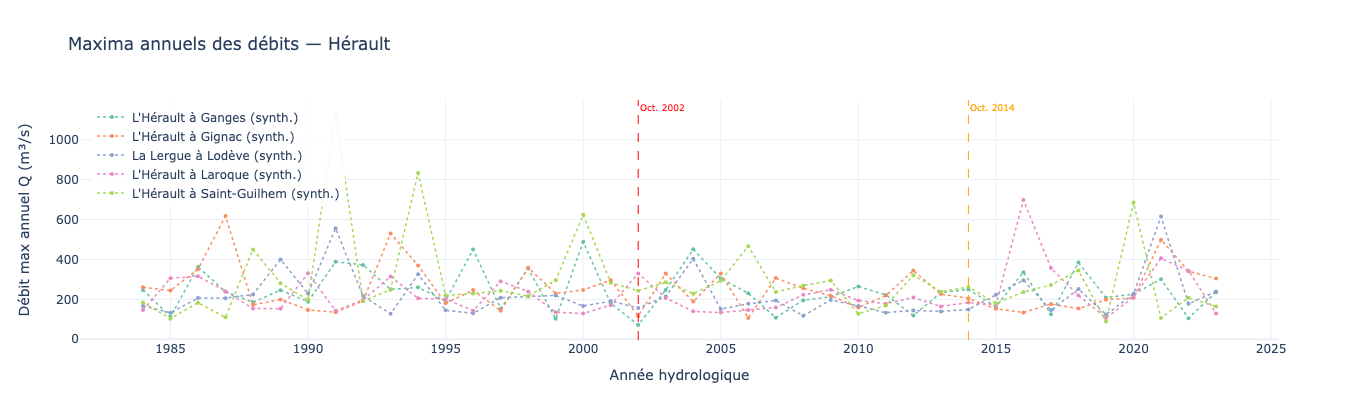

In [6]:
# ── Graphique : chroniques des maxima annuels (multi-stations) ──────────────
fig = go.Figure()
colors_stations = px.colors.qualitative.Set2

for i, s in enumerate(STATIONS_CLES):
    sub = df_series[df_series['code_station'] == s['code']].sort_values('year')
    if sub.empty:
        continue
    is_synth = sub['synthetique'].iloc[0]
    col   = colors_stations[i % len(colors_stations)]
    label = sub['nom'].iloc[0] + (' (synth.)' if is_synth else '')

    fig.add_trace(go.Scatter(
        x=sub['year'], y=sub['Qmax_m3s'],
        mode='lines+markers',
        name=label,
        line=dict(color=col, width=1.5,
                  dash='dot' if is_synth else 'solid'),
        marker=dict(size=4),
        hovertemplate='%{x} : %{y:.1f} m³/s<extra>' + label + '</extra>'
    ))

# Annotation crue Oct. 2002
fig.add_vline(x=2002, line_dash='dash', line_color='red', line_width=1,
              annotation_text='Oct. 2002', annotation_font_size=9,
              annotation_font_color='red')
fig.add_vline(x=2014, line_dash='dash', line_color='orange', line_width=1,
              annotation_text='Oct. 2014', annotation_font_size=9,
              annotation_font_color='orange')

fig.update_layout(
    title=f'Maxima annuels des débits — {DEPT_NAME}',
    xaxis_title='Année hydrologique',
    yaxis_title='Débit max annuel Q (m³/s)',
    height=420, template='plotly_white',
    legend=dict(x=0.01, y=0.99, bgcolor='rgba(255,255,255,0.85)')
)
fig.show()

## 3. Ajustement statistique — GEV, Gumbel, Log-Normale

| Distribution | Formule | Paramètres |
|--------------|---------|------------|
| **GEV** | $F(x) = \exp\{-[1 + \xi(x-\mu)/\sigma]^{-1/\xi}\}$ | ξ (forme), μ (loc), σ (échelle) |
| **Gumbel** | GEV avec ξ=0 : $F(x) = \exp\{-e^{-(x-u)/\alpha}\}$ | u (mode), α (échelle) |
| **Log-Normale** | $\ln X \sim \mathcal{N}(\mu_{\ln}, \sigma_{\ln}^2)$ | μ_ln, σ_ln |

**Ajustement** : MLE (maximum de vraisemblance) via `scipy.stats`  
**Positions de tracé empiriques** : Weibull $F(i) = i/(n+1)$ — retournant $T = (n+1)/i$

In [7]:
def fit_distributions(values, t_list=None):
    """
    Ajuste GEV, Gumbel et Log-Normale à une série de maxima annuels.
    Retourne un dict avec paramètres, quantiles, AIC et test KS.
    """
    if t_list is None:
        t_list = T_LIST
    data  = np.asarray(values, dtype=float)
    data  = data[np.isfinite(data) & (data > 0)]
    n     = len(data)
    if n < 8:
        return None

    pnce  = np.array([1 - 1/T for T in t_list])
    out   = {'n': n, 'data': data, 't_list': t_list, 'pnce': pnce}

    # Positions empiriques de Weibull
    sorted_desc = np.sort(data)[::-1]
    T_emp = (n + 1) / np.arange(1, n + 1)
    out['empirique'] = {'T': T_emp, 'Q': sorted_desc}

    def gof_ks(dist, params):
        ks, pv = stats.kstest(data, lambda x: dist.cdf(x, *params))
        return round(ks, 4), round(pv, 4)

    def aic(dist, params, k):
        ll = np.sum(dist.logpdf(data, *params))
        return round(2*k - 2*ll, 1)

    # ── GEV ──────────────────────────────────────────────────────────────────
    try:
        c, loc, scale = stats.genextreme.fit(data)
        q = stats.genextreme.ppf(pnce, c, loc, scale)
        ks, pv = gof_ks(stats.genextreme, (c, loc, scale))
        out['GEV'] = {
            'params': (c, loc, scale),
            'label':  f'GEV (ξ={c:.3f}, μ={loc:.1f}, σ={scale:.1f})',
            'color':  '#d7301f',
            'quantiles': q, 'ks': ks, 'pvalue': pv,
            'aic': aic(stats.genextreme, (c, loc, scale), 3)
        }
    except Exception as e:
        print(f'  GEV : {e}')

    # ── Gumbel ───────────────────────────────────────────────────────────────
    try:
        loc_g, sc_g = stats.gumbel_r.fit(data)
        q = stats.gumbel_r.ppf(pnce, loc_g, sc_g)
        ks, pv = gof_ks(stats.gumbel_r, (loc_g, sc_g))
        out['Gumbel'] = {
            'params': (loc_g, sc_g),
            'label':  f'Gumbel (u={loc_g:.1f}, α={sc_g:.1f})',
            'color':  '#2c7bb6',
            'quantiles': q, 'ks': ks, 'pvalue': pv,
            'aic': aic(stats.gumbel_r, (loc_g, sc_g), 2)
        }
    except Exception as e:
        print(f'  Gumbel : {e}')

    # ── Log-Normale ──────────────────────────────────────────────────────────
    try:
        s_ln, _, sc_ln = stats.lognorm.fit(data, floc=0)
        q = stats.lognorm.ppf(pnce, s_ln, 0, sc_ln)
        ks, pv = gof_ks(stats.lognorm, (s_ln, 0, sc_ln))
        out['LN2'] = {
            'params': (s_ln, 0, sc_ln),
            'label':  f'LN2 (μ_ln={np.log(sc_ln):.2f}, σ_ln={s_ln:.2f})',
            'color':  '#1a9641',
            'quantiles': q, 'ks': ks, 'pvalue': pv,
            'aic': aic(stats.lognorm, (s_ln, 0, sc_ln), 2)
        }
    except Exception as e:
        print(f'  LN2 : {e}')

    return out


# ── Application à la station principale ─────────────────────────────────────
main_station = STATIONS_CLES[0]
main_data    = df_series[df_series['code_station'] == main_station['code']]['Qmax_m3s'].values
fit          = fit_distributions(main_data)

print(f'Station : {main_station["nom"]} (n={fit["n"]} ans)')
print()

# Tableau des paramètres + test KS
rows_gof = []
for dist_key in ['GEV', 'Gumbel', 'LN2']:
    if dist_key in fit:
        d = fit[dist_key]
        rows_gof.append({'Distribution': dist_key, 'Label': d['label'],
                         'KS statistic': d['ks'], 'p-value KS': d['pvalue'],
                         'AIC': d['aic']})

df_gof = pd.DataFrame(rows_gof)
display(df_gof)

Station : L'Hérault à Ganges (n=40 ans)



,Distribution,Label,KS statistic,p-value KS,AIC
0,GEV,"GEV (ξ=0.094, μ=200.3, σ=87.5)",0.1040,0.7406,486.1
1,Gumbel,"Gumbel (u=196.0, α=85.0)",0.0875,0.8928,484.6
2,LN2,"LN2 (μ_ln=5.40, σ_ln=0.45)",0.0987,0.7948,485.4


## 4. Courbe des fréquences — Plotly

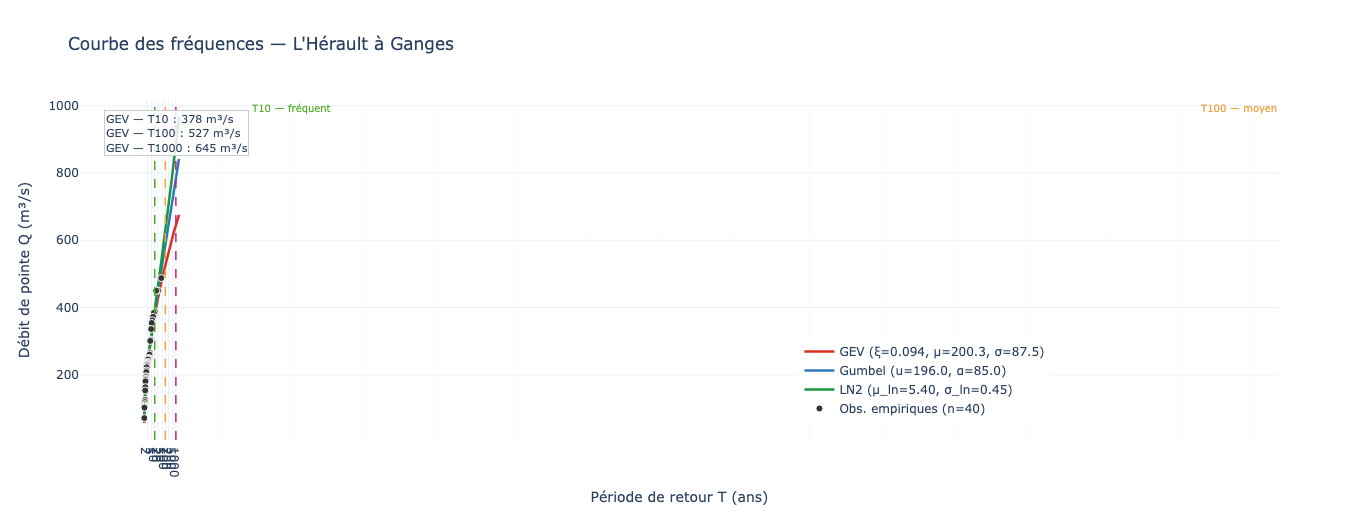

In [8]:
def plot_freq_curve(fit_res, title=None, ci_res=None):
    """
    Courbe de fréquences Plotly avec données empiriques + distributions ajustées.
    Axe X log (période de retour), axe Y débit (m³/s).
    """
    fig = go.Figure()

    # Grille dense pour les courbes théoriques (axe log)
    T_dense  = np.logspace(np.log10(1.01), np.log10(2000), 400)
    pnce_d   = 1 - 1/T_dense

    # Repères verticaux TRI
    for T_val, (col, lbl) in T_SCEN.items():
        fig.add_vline(x=T_val, line_dash='dash', line_color=col, line_width=1.5,
                      annotation_text=lbl, annotation_position='top right',
                      annotation_font_color=col, annotation_font_size=10)

    # Distributions ajustées
    for key, dist_obj, pnce_fn in [
        ('GEV',    stats.genextreme, lambda p, prm: stats.genextreme.ppf(p, *prm)),
        ('Gumbel', stats.gumbel_r,   lambda p, prm: stats.gumbel_r.ppf(p, *prm)),
        ('LN2',    stats.lognorm,    lambda p, prm: stats.lognorm.ppf(p, *prm)),
    ]:
        if key not in fit_res:
            continue
        d = fit_res[key]
        q_dense = pnce_fn(pnce_d, d['params'])

        fig.add_trace(go.Scatter(
            x=T_dense, y=q_dense,
            mode='lines', name=d['label'],
            line=dict(color=d['color'], width=2.5)
        ))

        # Intervalles de confiance bootstrap
        if ci_res and key in ci_res:
            ci = ci_res[key]
            T_arr = np.array(fit_res['t_list'])
            fig.add_trace(go.Scatter(
                x=list(T_arr) + list(T_arr[::-1]),
                y=list(ci['upper']) + list(ci['lower'][::-1]),
                fill='toself',
                fillcolor='rgba(150,150,150,0.15)',
                line=dict(width=0),
                name=f'IC 95% {key}',
                showlegend=True
            ))

    # Points empiriques (Weibull)
    emp = fit_res['empirique']
    fig.add_trace(go.Scatter(
        x=emp['T'], y=emp['Q'],
        mode='markers',
        name=f'Obs. empiriques (n={fit_res["n"]})',
        marker=dict(color='#333', size=7, symbol='circle',
                    line=dict(color='white', width=1))
    ))

    # Tableau quantiles TRI (annotation)
    if 'GEV' in fit_res:
        d = fit_res['GEV']
        q10   = d['quantiles'][fit_res['t_list'].index(10)]  if 10  in fit_res['t_list'] else '—'
        q100  = d['quantiles'][fit_res['t_list'].index(100)] if 100 in fit_res['t_list'] else '—'
        q1000 = d['quantiles'][fit_res['t_list'].index(1000)] if 1000 in fit_res['t_list'] else '—'
        fig.add_annotation(
            x=0.02, y=0.97, xref='paper', yref='paper',
            text=(f'GEV — T10 : {q10:.0f} m³/s<br>'
                  f'GEV — T100 : {q100:.0f} m³/s<br>'
                  f'GEV — T1000 : {q1000:.0f} m³/s'),
            showarrow=False, align='left',
            bgcolor='rgba(255,255,255,0.85)',
            bordercolor='#ccc', borderwidth=1,
            font=dict(size=11)
        )

    fig.update_layout(
        title=title or 'Courbe des fréquences',
        xaxis=dict(
            title='Période de retour T (ans)',
            type='log',
            tickvals=[2, 5, 10, 20, 50, 100, 200, 500, 1000],
            ticktext=['2', '5', '10', '20', '50', '100', '200', '500', '1000'],
            minor=dict(showgrid=True)
        ),
        yaxis=dict(title='Débit de pointe Q (m³/s)'),
        height=520, template='plotly_white',
        legend=dict(x=0.60, y=0.05, bgcolor='rgba(255,255,255,0.9)')
    )
    return fig


# ── Tracé pour la station principale ────────────────────────────────────────
fig_freq = plot_freq_curve(
    fit,
    title=f'Courbe des fréquences — {main_station["nom"]}'
)
fig_freq.show()

## 5. Intervalles de confiance — Bootstrap (n=1000)

La méthode bootstrap rééchantillonne la série observée (avec remise) 1000 fois, ajuste la distribution à chaque tirage et calcule les percentiles 2,5% et 97,5% des quantiles.  
Cela donne l'**incertitude d'estimation** liée à la longueur de la série (effet taille d'échantillon).

Bootstrap GEV (n=1000 tirages)...


,T (ans),GEV Q (m³/s),IC 2.5% (m³/s),IC 97.5% (m³/s)
0,2,231.9,72.1,2.713000e+02
1,5,322.7,258.3,3.100330e+04
2,10,377.8,329.2,4.092948e+06
3,20,427.1,372.5,5.001708e+08
4,50,486.1,408.3,2.616444e+11
5,100,527.1,433.6,3.060854e+13
6,200,565.3,450.5,3.254858e+15
7,500,612.1,467.5,1.475341e+18
8,1000,644.9,476.6,1.695204e+20


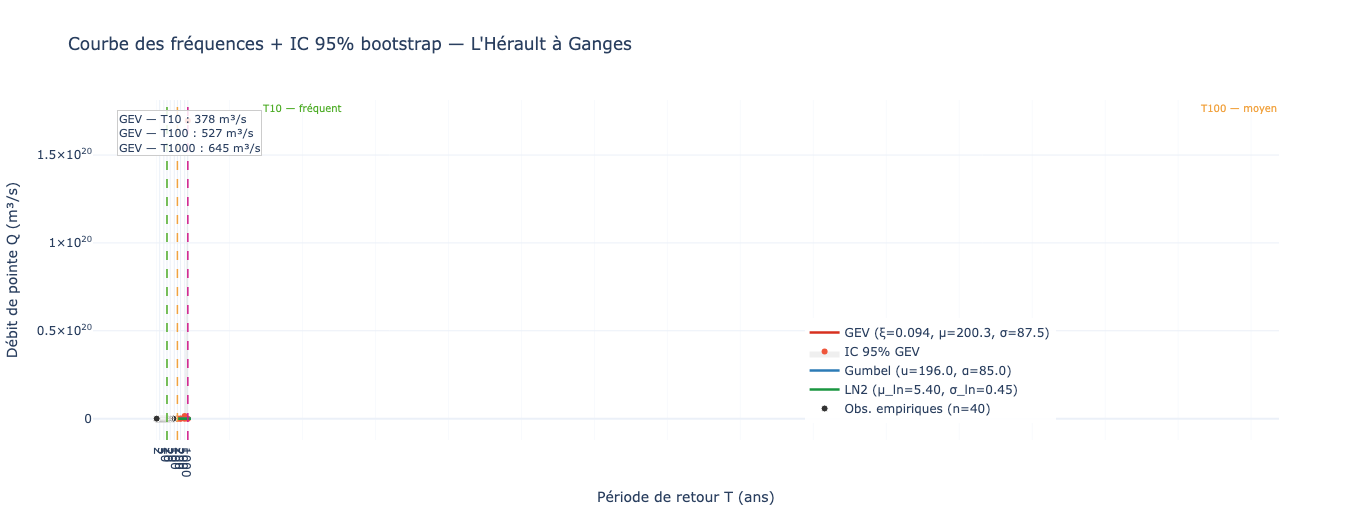

In [9]:
def bootstrap_ci(data, dist_key='GEV', n_boot=1000, t_list=None, seed=42):
    """
    Intervalles de confiance bootstrap à 95% pour les quantiles de retour.
    Retourne dict avec 'lower', 'median', 'upper' (arrays de len=len(t_list)).
    """
    if t_list is None:
        t_list = T_LIST
    rng   = np.random.default_rng(seed)
    data  = np.asarray(data)
    n     = len(data)
    pnce  = np.array([1 - 1/T for T in t_list])
    boot  = np.full((n_boot, len(t_list)), np.nan)

    for i in range(n_boot):
        sample = rng.choice(data, size=n, replace=True)
        try:
            if dist_key == 'GEV':
                p = stats.genextreme.fit(sample)
                boot[i] = stats.genextreme.ppf(pnce, *p)
            elif dist_key == 'Gumbel':
                p = stats.gumbel_r.fit(sample)
                boot[i] = stats.gumbel_r.ppf(pnce, *p)
            elif dist_key == 'LN2':
                p = stats.lognorm.fit(sample, floc=0)
                boot[i] = stats.lognorm.ppf(pnce, *p)
        except:
            pass

    return {
        'lower':  np.nanpercentile(boot, 2.5,  axis=0),
        'median': np.nanpercentile(boot, 50.0, axis=0),
        'upper':  np.nanpercentile(boot, 97.5, axis=0),
        't_list': t_list
    }


print('Bootstrap GEV (n=1000 tirages)...')
ci_gev = bootstrap_ci(main_data, dist_key='GEV', n_boot=1000)

# Tableau des quantiles avec IC
df_ci = pd.DataFrame({
    'T (ans)':    T_LIST,
    'GEV Q (m³/s)':   np.round(fit['GEV']['quantiles'], 1),
    'IC 2.5% (m³/s)': np.round(ci_gev['lower'], 1),
    'IC 97.5% (m³/s)': np.round(ci_gev['upper'], 1),
})
display(df_ci)

# Courbe avec IC
fig_ci = plot_freq_curve(
    fit,
    title=f'Courbe des fréquences + IC 95% bootstrap — {main_station["nom"]}',
    ci_res={'GEV': ci_gev}
)
fig_ci.show()

## 6. Comparaison multi-stations — quantiles TRI

Ajustement GEV multi-stations...
  L'Hérault à Ganges                         T10=377.8  T100=527.1  T1000=644.9 m³/s
  L'Hérault à Gignac                         T10=394.9  T100=708.8  T1000=1177.8 m³/s
  La Lergue à Lodève                         T10=335.2  T100=819.1  T1000=2121.4 m³/s
  L'Hérault à Laroque                        T10=255.0  T100=7974.3  T1000=387051.2 m³/s
  L'Hérault à Saint-Guilhem                  T10=3223742266.5  T100=8.421178093697052e+19  T1000=1.4229664127814586e+30 m³/s



,code_station,nom,n,Q_T10,Q_T100,Q_T1000
0,Y210001001,L'Hérault à Ganges,40,3.778000e+02,5.271000e+02,6.449000e+02
1,Y214001002,L'Hérault à Gignac,40,3.949000e+02,7.088000e+02,1.177800e+03
2,Y221001001,La Lergue à Lodève,40,3.352000e+02,8.191000e+02,2.121400e+03
3,Y210002001,L'Hérault à Laroque,40,2.550000e+02,7.974300e+03,3.870512e+05
4,Y214002001,L'Hérault à Saint-Guilhem,40,3.223742e+09,8.421178e+19,1.422966e+30


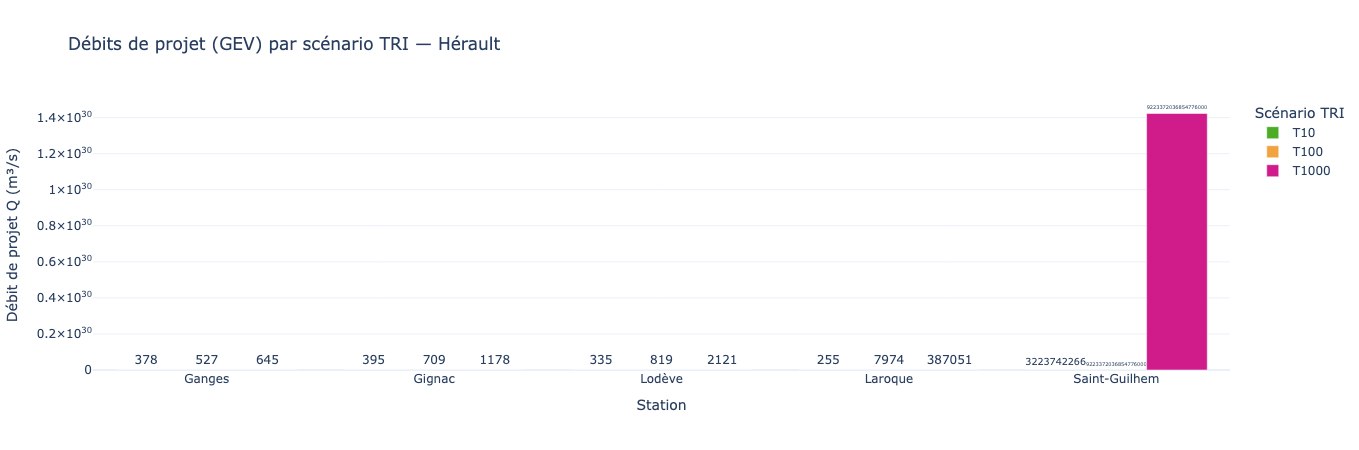

In [10]:
# ── Ajustement GEV sur toutes les stations ───────────────────────────────────
print('Ajustement GEV multi-stations...')
rows_multistat = []
fits_all = {}

for s in STATIONS_CLES:
    code = s['code']
    nom  = s['nom']
    vals = df_series[df_series['code_station'] == code]['Qmax_m3s'].values
    if len(vals) < 8:
        print(f'  {code} : série trop courte ({len(vals)})')
        continue
    f = fit_distributions(vals)
    if f is None or 'GEV' not in f:
        continue
    fits_all[code] = f
    gev_q = f['GEV']['quantiles']
    t_arr = f['t_list']
    row = {'code_station': code, 'nom': nom, 'n': f['n']}
    for T_val in [10, 100, 1000]:
        if T_val in t_arr:
            row[f'Q_T{T_val}'] = round(gev_q[t_arr.index(T_val)], 1)
    rows_multistat.append(row)
    print(f'  {nom[:40]:<42} T10={row.get("Q_T10","—")}  T100={row.get("Q_T100","—")}  T1000={row.get("Q_T1000","—")} m³/s')

df_ms = pd.DataFrame(rows_multistat)
print()
display(df_ms)

# ── Graphique groupé — débits TRI par station ────────────────────────────────
fig_ms = go.Figure()
T_scenarios = [
    ('Q_T10',   '#4dac26', 'T10'),
    ('Q_T100',  '#f1a340', 'T100'),
    ('Q_T1000', '#d01c8b', 'T1000'),
]
noms_courts = [n.replace("L'Hérault à ", '').replace('La Lergue à ', '').replace("L'Hérault à Saint-Guilhem", 'St-Guilhem') 
               for n in df_ms['nom']]

for col, color, label in T_scenarios:
    if col in df_ms.columns:
        fig_ms.add_trace(go.Bar(
            name=label, x=noms_courts, y=df_ms[col],
            marker_color=color, text=df_ms[col].round(0).astype(int),
            textposition='outside',
            hovertemplate=f'{label} : %{{y:.1f}} m³/s<extra>%{{x}}</extra>'
        ))

fig_ms.update_layout(
    title=f'Débits de projet (GEV) par scénario TRI — {DEPT_NAME}',
    xaxis_title='Station',
    yaxis_title='Débit de projet Q (m³/s)',
    barmode='group',
    height=450, template='plotly_white',
    legend=dict(title='Scénario TRI')
)
fig_ms.show()

## 7. Distribution des maxima — analyse exploratoire

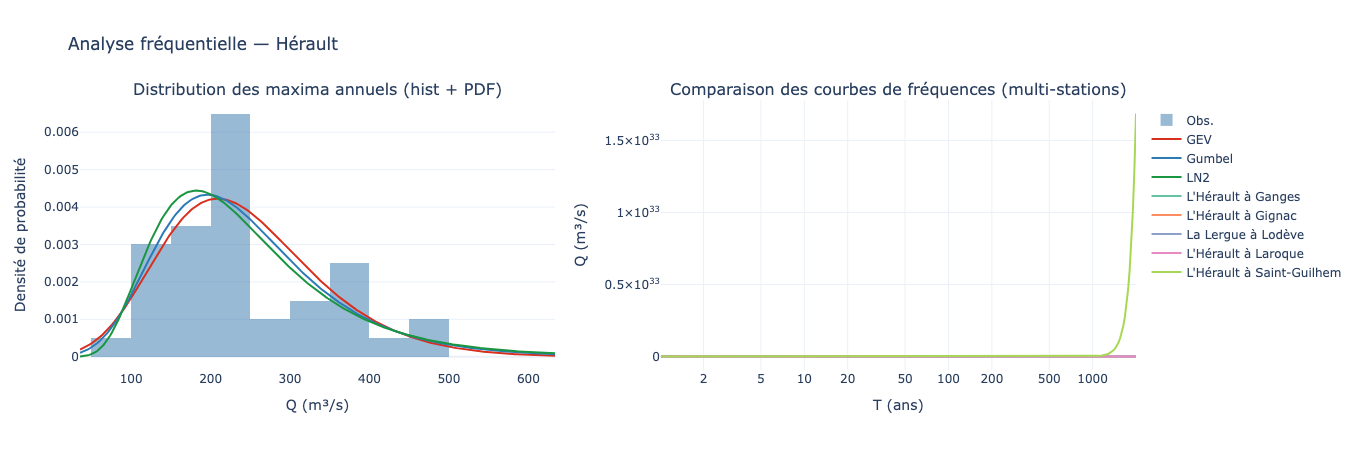

In [11]:
# ── Histogramme + PDF ajustées (station principale) ──────────────────────────
fig_hist = make_subplots(rows=1, cols=2,
    subplot_titles=('Distribution des maxima annuels (hist + PDF)',
                    'Comparaison des courbes de fréquences (multi-stations)'))

# Histogramme
fig_hist.add_trace(
    go.Histogram(
        x=main_data, nbinsx=20,
        name='Obs.', opacity=0.55,
        marker_color='steelblue',
        histnorm='probability density',
        hovertemplate='[%{x:.0f}, …] : densité %{y:.4f}<extra></extra>'
    ), row=1, col=1
)

# PDFs
x_range = np.linspace(main_data.min() * 0.5, main_data.max() * 1.3, 300)
for key, dist_obj, col_pdf in [
    ('GEV',    stats.genextreme, '#d7301f'),
    ('Gumbel', stats.gumbel_r,   '#2c7bb6'),
    ('LN2',    stats.lognorm,    '#1a9641'),
]:
    if key in fit:
        pdf_vals = dist_obj.pdf(x_range, *fit[key]['params'])
        fig_hist.add_trace(
            go.Scatter(x=x_range, y=pdf_vals, mode='lines',
                       name=key, line=dict(color=col_pdf, width=2)),
            row=1, col=1
        )

# Courbes de fréquences multi-stations (GEV)
T_dense  = np.logspace(np.log10(1.01), np.log10(2000), 300)
pnce_d   = 1 - 1/T_dense
cols_s   = px.colors.qualitative.Set2

for i, s in enumerate(STATIONS_CLES):
    code = s['code']
    if code not in fits_all or 'GEV' not in fits_all[code]:
        continue
    f_gev = fits_all[code]['GEV']
    q_d   = stats.genextreme.ppf(pnce_d, *f_gev['params'])
    fig_hist.add_trace(
        go.Scatter(x=T_dense, y=q_d, mode='lines',
                   name=s['nom'], line=dict(color=cols_s[i % len(cols_s)], width=2)),
        row=1, col=2
    )

fig_hist.update_xaxes(title_text='Q (m³/s)',               row=1, col=1)
fig_hist.update_yaxes(title_text='Densité de probabilité', row=1, col=1)
fig_hist.update_xaxes(title_text='T (ans)', type='log',
                      tickvals=[2,5,10,20,50,100,200,500,1000],
                      ticktext=['2','5','10','20','50','100','200','500','1000'],
                      row=1, col=2)
fig_hist.update_yaxes(title_text='Q (m³/s)', row=1, col=2)

fig_hist.update_layout(
    title_text=f'Analyse fréquentielle — {DEPT_NAME}',
    height=450, template='plotly_white',
    legend=dict(x=1.01, y=0.98, traceorder='normal')
)
fig_hist.show()

## 8. Export & résumé

In [ ]:
# ── Export CSV ────────────────────────────────────────────────────────────────
# 1. Série des maxima annuels
path_series = f'{DATA_DIR}/annual_max_herault.csv'
df_series.to_csv(path_series, index=False)
print(f'✅ Maxima annuels : {path_series}')

# 2. Quantiles TRI multi-stations
path_quantiles = f'{DATA_DIR}/quantiles_tri_herault.csv'
df_ms.to_csv(path_quantiles, index=False)
print(f'✅ Quantiles TRI  : {path_quantiles}')

# 3. Tableau détaillé des quantiles (station principale, toutes distributions)
rows_q = []
for key in ['GEV', 'Gumbel', 'LN2']:
    if key in fit:
        for T_val, q_val in zip(T_LIST, fit[key]['quantiles']):
            rows_q.append({'Distribution': key, 'T_ans': T_val,
                           'Q_m3s': round(q_val, 1),
                           'station': main_station['code']})
df_q = pd.DataFrame(rows_q)
path_q_detail = f'{DATA_DIR}/freq_quantiles_detail.csv'
df_q.to_csv(path_q_detail, index=False)
print(f'✅ Quantiles détail : {path_q_detail}')

# ── Tableau de synthèse final ────────────────────────────────────────────────
print()
print('='*65)
print(f'  SYNTHÈSE — Analyse fréquentielle {DEPT_NAME}')
print('='*65)
print(f'  Stations analysées  : {len(df_ms)}')
print(f'  Meilleure station   : {main_station["nom"]} (n={fit["n"]} ans)')
gev_p = fit['GEV']['params']
print(f'  GEV params          : ξ={gev_p[0]:.3f}, μ={gev_p[1]:.1f}, σ={gev_p[2]:.1f}')
print(f'  GEV — KS test       : D={fit["GEV"]["ks"]:.4f}  p={fit["GEV"]["pvalue"]:.4f}')
print()

summary_df = pd.DataFrame({
    'Scénario TRI':  ['T10 (fréquent)', 'T100 (moyen)', 'T1000 (extrême)'],
    'GEV (m³/s)':   [round(fit['GEV']['quantiles'][T_LIST.index(T)], 1)
                     for T in [10, 100, 1000]],
    'Gumbel (m³/s)': [round(fit['Gumbel']['quantiles'][T_LIST.index(T)], 1)
                      for T in [10, 100, 1000]] if 'Gumbel' in fit else ['—']*3,
    'LN2 (m³/s)':   [round(fit['LN2']['quantiles'][T_LIST.index(T)], 1)
                     for T in [10, 100, 1000]] if 'LN2' in fit else ['—']*3,
})
display(summary_df)

print()
print('→ Suite : 02a_dem_preprocessing.ipynb  |  06a_risk_mapping.ipynb')